<a href="https://colab.research.google.com/github/tamburins/ESAA-2022-/blob/main/DNN_1128.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/qiangwu2023/DNN_case1_interval.git

Cloning into 'DNN_case1_interval'...
remote: Enumerating objects: 433, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 433 (delta 42), reused 26 (delta 26), pack-reused 376 (from 1)
Receiving objects: 100% (433/433), 3.11 MiB | 6.32 MiB/s, done.
Resolving deltas: 100% (290/290), done.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


# 여기부터 데이터 로드


| x-variable | SUPPORT original variable          |
| ---------- | ---------------------------------- |
| **x0**     | age                                |
| **x1**     | sex                                |
| **x2**     | number of comorbidities ? 단톡방에선 race라는디           |
| **x3**     | race  ? 이게 number of comorbidities라는디?                             |
| **x4**     | diabetes                           |
| **x5**     | dementia                           |
| **x6**     | cancer (0=no, 1=yes, 2=metastatic) |
| **x7**     | heart rate                         |
| **x8**     | mean arterial blood pressure       |
| **x9**     | respiration rate                   |
| **x10**    | temperature                        |
| **x11**    | sodium                             |
| **x12**    | white blood cell count             |
| **x13**    | creatinine                         |


In [ ]:
!pip install lifelines scikit-learn pandas --quiet


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.7 MB/s eta 0:00:00


# Deep1

In [ ]:
!git clone https://github.com/qiangwu2023/DNN_case1_interval.git
%cd DNN_case1_interval/Model_Deep1


fatal: destination path 'DNN_case1_interval' already exists and is not an empty directory.
/content/DNN_case1_interval/Model_Deep1


In [ ]:
!ls -R .


.:
Beta_estimate.py     g_additive.py	    iteration_linear.py
B_spline3.py	     g_deep.py		    Least_FD.py
C_estimation.py      g_linear.py	    Main3.py
data_generator.py    I_spline.py	    __pycache__
fig_g_3_t.jpeg	     iteration_additive.py  result_error_deep1_t.csv
fig_Lambda_3_t.jpeg  iteration_deep.py	    result_re_deep1_t.csv

./__pycache__:
Beta_estimate.cpython-310.pyc	g_linear.cpython-310.pyc
Beta_estimate.cpython-39.pyc	g_linear.cpython-39.pyc
B_spline3.cpython-310.pyc	I_spline.cpython-310.pyc
B_spline3.cpython-39.pyc	I_spline.cpython-39.pyc
C_estimation.cpython-310.pyc	iteration_additive.cpython-310.pyc
C_estimation.cpython-39.pyc	iteration_additive.cpython-39.pyc
data_generator.cpython-310.pyc	iteration_deep.cpython-310.pyc
data_generator.cpython-39.pyc	iteration_deep.cpython-39.pyc
g_additive.cpython-310.pyc	iteration_linear.cpython-310.pyc
g_additive.cpython-39.pyc	iteration_linear.cpython-39.pyc
g_deep.cpython-310.pyc		Least_FD.cpython-310.pyc
g_deep.cpython-39.pyc		Lea

In [ ]:
# install package
!pip install numpy pandas matplotlib scipy torch


#데이터 로딩

In [ ]:
!pip install pycox torchtuples --quiet

from pycox.datasets import support
import pandas as pd

# PyCox 내부 SUPPORT dataset 로드
support_df = support.read_df()

support_df.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,x13,duration,event
0,82.709961,1.0,2.0,1.0,0.0,0.0,0.0,160.0,55.0,16.0,38.195309,142.0,19.000000,1.099854,30.0,1
1,79.660950,1.0,0.0,1.0,0.0,0.0,1.0,54.0,67.0,16.0,38.000000,142.0,10.000000,0.899902,1527.0,0
2,23.399990,1.0,2.0,3.0,0.0,0.0,1.0,87.0,144.0,45.0,37.296879,130.0,5.199219,1.199951,96.0,1
3,53.075989,1.0,4.0,3.0,0.0,0.0,0.0,55.0,100.0,18.0,36.000000,135.0,8.699219,0.799927,892.0,0
4,71.794983,0.0,1.0,1.0,0.0,0.0,0.0,65.0,135.0,40.0,38.593750,146.0,0.099991,0.399963,7.0,1


# EDA

## 카테고리컬 / 연속형 확인

In [77]:
import pandas as pd
import numpy as np
from pycox.datasets import support

cat_vars = []
cont_vars = []

for col in support_df.columns:
    uniq = support_df[col].dropna().unique()
    nunique = len(uniq)

    # 정수 여부 판정
    is_int = np.all(np.equal(np.mod(uniq, 1), 0))

    if nunique <= 10 and is_int:
        cat_vars.append(col)
    else:
        cont_vars.append(col)

cat_vars, cont_vars


(['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'event'],
 ['x0', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'duration'])

## cox ph lasso

In [119]:
!pip install scikit-survival


In [120]:
import pandas as pd
import numpy as np
import sksurv

from pycox.datasets import support
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.util import Surv


# ----------------------------------------------------
# 1) 데이터 로딩
# ----------------------------------------------------
df = support.read_df()

time_col = "duration"
event_col = "event"

# Categorical 변수 (당신이 말한 리스트)
categorical_cols = ['x1','x2','x3','x4','x5','x6']

# 연속형 변수 (= 나머지 중 시간/이벤트 제외)
continuous_cols = [c for c in df.columns
                   if c not in categorical_cols + [time_col, event_col]]


# ----------------------------------------------------
# 2) One-hot 인코딩 + 표준화 파이프라인 구성
# ----------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_cols),
        ("cont", StandardScaler(), continuous_cols),
    ]
)

# scikit-survival은 (event, time) 구조 필요
y = Surv.from_arrays(event=df[event_col].astype(bool),
                     time=df[time_col].astype(float))


# ----------------------------------------------------
# 3) Lasso Cox 모델 정의
# ----------------------------------------------------
# l1_ratio = 1 → Lasso
# alpha 값은 50개 자동 탐색 (glmnet 스타일)
cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, n_alphas=50)


# ----------------------------------------------------
# 4) Pipeline으로 묶기
# ----------------------------------------------------
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("cox_lasso", cox_lasso)
])


# ----------------------------------------------------
# 5) Train/Test Split
# ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=[time_col, event_col]),
    y,
    test_size=0.2,
    random_state=42
)


# ----------------------------------------------------
# 6) 모델 학습
# ----------------------------------------------------
model.fit(X_train, y_train)

print("Lasso CoxPH 학습 완료!")


# ----------------------------------------------------
# 7) 변수 선택
# ----------------------------------------------------
import re
import re
import numpy as np

def get_selected_variables(model, categorical_cols, continuous_cols, alpha_idx=-1):
    """
    model: fitted Pipeline (preprocess + cox_lasso)
    categorical_cols: ['x1','x2','x3','x4','x5','x6']
    continuous_cols: 연속형 변수 리스트
    alpha_idx: coef_에서 사용할 열 인덱스 (기본: 마지막 alpha)
    """

    # 1) dummy + scaled 변수 전체 이름 추출
    ohe  = model.named_steps["preprocess"].named_transformers_["cat"]
    # cont = model.named_steps["preprocess"].named_transformers_["cont"]  # 필요시 사용

    dummy_feature_names = ohe.get_feature_names_out(categorical_cols)
    cont_feature_names  = continuous_cols

    feature_names = list(dummy_feature_names) + list(cont_feature_names)

    # 2) coef 가져오기 (n_features, n_alphas)
    coefs = model.named_steps["cox_lasso"].coef_

    if coefs.ndim == 2:
        # alpha 경로 중에서 하나 선택 (기본: 마지막 alpha)
        coefs_use = coefs[:, alpha_idx]
    else:
        coefs_use = coefs

    # 3) 0이 아닌 계수의 feature 이름
    selected_features = [
        name for name, coef in zip(feature_names, coefs_use)
        if coef != 0.0
    ]

    # 4) 변수 단위로 그룹핑 (dummy → 원래 변수명만 남기기)
    selected_vars = set()
    for f in selected_features:
        # 예: x1_2 → x1
        base = re.split(r"_", f)[0]
        selected_vars.add(base)

    return sorted(selected_vars)

selected = get_selected_variables(
    model=model,
    categorical_cols=['x1','x2','x3','x4','x5','x6'],
    continuous_cols=continuous_cols
)

print("선택된 변수들:")
for v in selected:
    print("-", v)



Lasso CoxPH 학습 완료!
선택된 변수들:
- x0
- x1
- x10
- x11
- x12
- x13
- x2
- x3
- x4
- x5
- x6
- x7
- x8
- x9


In [121]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cont = continuous_cols

dummy_feature_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names = dummy_feature_names + cont

print(feature_names)


['x1_1.0', 'x2_1.0', 'x2_2.0', 'x2_3.0', 'x2_4.0', 'x2_5.0', 'x2_6.0', 'x2_7.0', 'x2_8.0', 'x2_9.0', 'x3_1.0', 'x3_2.0', 'x3_3.0', 'x3_4.0', 'x3_5.0', 'x4_1.0', 'x5_1.0', 'x6_1.0', 'x6_2.0', 'x0', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13']


In [122]:
import pandas as pd

coefs = model.named_steps["cox_lasso"].coef_
alpha_idx = -1  # 마지막 alpha

coef_vec = coefs[:, alpha_idx]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef_vec
})

print(coef_df)


   feature      coef
0   x1_1.0 -0.055939
1   x2_1.0  0.115080
2   x2_2.0  0.125680
3   x2_3.0  0.101630
4   x2_4.0  0.161179
5   x2_5.0  0.176811
6   x2_6.0  0.082703
7   x2_7.0  0.396963
8   x2_8.0  1.561763
9   x2_9.0 -1.696374
10  x3_1.0 -0.153455
11  x3_2.0 -0.108814
12  x3_3.0 -0.208424
13  x3_4.0 -0.013140
14  x3_5.0 -0.027362
15  x4_1.0  0.021614
16  x5_1.0  0.259066
17  x6_1.0 -0.719701
18  x6_2.0 -0.302903
19      x0  0.198618
20      x7 -0.086901
21      x8  0.076076
22      x9  0.030013
23     x10 -0.003874
24     x11 -0.001100
25     x12  0.034631
26     x13  0.073210


In [123]:
import pandas as pd
import numpy as np

def get_sorted_coef_df(model, categorical_cols, continuous_cols, alpha_idx=-1):
    """
    alpha_idx: coef 행렬에서 선택할 규제 강도 index (기본: 마지막 alpha)
    """
    # ----------------------------
    # 1) feature 이름 구성
    # ----------------------------
    ohe = model.named_steps["preprocess"].named_transformers_["cat"]

    dummy_feature_names = list(ohe.get_feature_names_out(categorical_cols))
    cont_feature_names  = continuous_cols

    feature_names = dummy_feature_names + cont_feature_names

    # ----------------------------
    # 2) coef 벡터 선택
    # ----------------------------
    coefs = model.named_steps["cox_lasso"].coef_
    if coefs.ndim == 2:
        coef_vec = coefs[:, alpha_idx]   # 특정 alpha column 선택
    else:
        coef_vec = coefs

    # ----------------------------
    # 3) DataFrame 생성 + 정렬
    # ----------------------------
    df_coef = pd.DataFrame({
        "feature": feature_names,
        "coef": coef_vec,
        "abs_coef": np.abs(coef_vec)
    })

    df_sorted = df_coef.sort_values("abs_coef", ascending=False).reset_index(drop=True)

    return df_sorted
coef_sorted = get_sorted_coef_df(
    model=model,
    categorical_cols=['x1','x2','x3','x4','x5','x6'],
    continuous_cols=continuous_cols,
    alpha_idx=-1  # 마지막 alpha 사용
)

print(coef_sorted)


   feature      coef  abs_coef
0   x2_9.0 -1.696374  1.696374
1   x2_8.0  1.561763  1.561763
2   x6_1.0 -0.719701  0.719701
3   x2_7.0  0.396963  0.396963
4   x6_2.0 -0.302903  0.302903
5   x5_1.0  0.259066  0.259066
6   x3_3.0 -0.208424  0.208424
7       x0  0.198618  0.198618
8   x2_5.0  0.176811  0.176811
9   x2_4.0  0.161179  0.161179
10  x3_1.0 -0.153455  0.153455
11  x2_2.0  0.125680  0.125680
12  x2_1.0  0.115080  0.115080
13  x3_2.0 -0.108814  0.108814
14  x2_3.0  0.101630  0.101630
15      x7 -0.086901  0.086901
16  x2_6.0  0.082703  0.082703
17      x8  0.076076  0.076076
18     x13  0.073210  0.073210
19  x1_1.0 -0.055939  0.055939
20     x12  0.034631  0.034631
21      x9  0.030013  0.030013
22  x3_5.0 -0.027362  0.027362
23  x4_1.0  0.021614  0.021614
24  x3_4.0 -0.013140  0.013140
25     x10 -0.003874  0.003874
26     x11 -0.001100  0.001100


# current data status 변환 & fold

In [124]:
import numpy as np
from sklearn.model_selection import KFold

def make_folds_with_current_status(df, K, time_col, event_col, z_cols_expanded, x_cols,
                                   lam=None, seed=42):
    """
    df: 원본 데이터
    K: K-fold 개수
    time_col: 생존 시간 (duration/intxsurv 등)
    event_col: event indicator
    z_cols, x_cols: Z/X 변수
    lam: Exponential 관측 시점 lambda (None이면 자동 추정)
    """

    kf = KFold(n_splits=K, shuffle=True, random_state=seed)

    folds = []

    for fold_id, (train_idx, test_idx) in enumerate(kf.split(df)):
        df_train = df.iloc[train_idx].copy()
        df_test  = df.iloc[test_idx].copy()

        # ---- current-status 변환 ----
        cs_train = make_current_status_data(df_train,
                                            time_col=time_col,
                                            event_col=event_col,
                                            z_cols=z_cols_expanded,
                                            x_cols=x_cols_expanded,
                                            lam=lam,
                                            seed=seed + fold_id)

        cs_test = make_current_status_data(df_test,
                                           time_col=time_col,
                                           event_col=event_col,
                                           z_cols=z_cols,
                                           x_cols=x_cols,
                                           lam=lam,
                                           seed=seed + fold_id)

        folds.append({
            "fold": fold_id,
            "train": cs_train,
            "test": cs_test,
            "train_index": train_idx,
            "test_index": test_idx
        })

    return folds


In [125]:
from sklearn.preprocessing import StandardScaler

def make_current_status_data(df, time_col, event_col, z_cols, x_cols,
                             lam=None, seed=42):

    # duration, event만 결측 제거
    df = df.dropna(subset=[time_col, event_col]).copy()

    T = df[time_col].values.astype(float)
    E = df[event_col].values.astype(int)

    rng = np.random.default_rng(seed)

    # --- observation time C 생성 ---
    if lam is None:
        lam = 1 / np.mean(T)

    C_raw = rng.exponential(scale=1/lam, size=len(T))
    C = np.minimum(C_raw, T.max())

    Delta = ((T <= C) & (E == 1)).astype(int)

    df["C"] = C
    df["Delta"] = Delta
    C_max = df["C"].max()
    df["U_scaled"] = df["C"] / C_max

    # Z 변수 스케일링
    scaler = StandardScaler()
    for col in z_cols:     # z_cols MUST be expanded dummy + continuous
        df[f"Z_{col}"] = scaler.fit_transform(df[[col]])

    # X 결측 보정
    for col in x_cols:
        df[col] = df[col].fillna(-1)

    # 최종 Z 목록: 모든 Z_ 접두사 컬럼
    z_final = [c for c in df.columns if c.startswith("Z_")]

    return {
        "df": df,
        "Z_cols": z_final,
        "X_cols": x_cols,
        "time_col": time_col,
        "event_col": event_col,
        "C_max": C_max
    }


# MODELING

## Est_deep

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# --------------------------------------------------------
# Torch version of I-spline (baseline cumulative hazard)
# --------------------------------------------------------
def I_spline_torch(m, c0, U, nodevec):
    """
    I-spline basis in torch.
    c0 : (m,) learnable parameters
    U : (n,) tensor
    nodevec : numpy array of knots (m+2)
    """
    # nodevec to torch
    kv = torch.tensor(nodevec, dtype=torch.float32, device=U.device)

    # (n, m) basis matrix
    n = U.shape[0]
    basis = torch.zeros((n, m), dtype=torch.float32, device=U.device)

    for j in range(m):
        left = kv[j]
        right = kv[j+2]   # cubic I-spline for m knots
        width = right - left
        width = torch.clamp(width, min=1e-6)

        # linear I-spline construction
        b = (U - left) / width
        b = torch.clamp(b, min=0.0, max=1.0)
        basis[:, j] = b

    # Λ(U) = sum_j c0_j * I_j(U)
    return basis @ c0


# --------------------------------------------------------
# Deep Partially Linear Cox Model (DPLCM) with learnable c0
# --------------------------------------------------------
def Est_deep(train_data, X_test,
             n_layer, n_node,
             n_lr, n_epoch,
             nodevec, m):

    # 1) numpy to torch
    Z = torch.tensor(train_data['Z'], dtype=torch.float32)
    X = torch.tensor(train_data['X'], dtype=torch.float32)
    U = torch.tensor(train_data['U'], dtype=torch.float32)
    De = torch.tensor(train_data['De'], dtype=torch.float32)

    Xtest = torch.tensor(X_test, dtype=torch.float32)

    n, p_z = Z.shape
    _, p_x = X.shape

    # ----------------------------------------------------
    # 2) Network g(X)
    # ----------------------------------------------------
    class NetG(nn.Module):
        def __init__(self, p, n_layer, n_node):
            super().__init__()
            layers = []
            d = p
            for _ in range(n_layer):
                layers.append(nn.Linear(d, n_node))
                layers.append(nn.ReLU())
                d = n_node
            layers.append(nn.Linear(d, 1))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x).squeeze(-1)

    net_g = NetG(p_x, n_layer, n_node)

    # ----------------------------------------------------
    # 3) Learnable parameters: β_z and c0
    # ----------------------------------------------------
  # 3) Learnable parameters: β_z and c0
    beta_param = torch.zeros(p_z, requires_grad=True)
    # 🔴 기존: torch.zeros(m, requires_grad=True)
    c0_param = torch.full((m,), 0.1, requires_grad=True)  # 작은 양수로 초기화

    params = list(net_g.parameters()) + [beta_param, c0_param]
    optimizer = optim.Adam(params, lr=n_lr, weight_decay=1e-4)
    eps = 1e-7

    for epoch in range(n_epoch):
        optimizer.zero_grad()

        g_train = net_g(X)
        eta = (Z * beta_param).sum(dim=1) + g_train
        eta = torch.clamp(eta, -6.0, 6.0)

        Lambda_U = I_spline_torch(m, c0_param, U, nodevec)
        # 🔴 하한 clamp 제거 또는 아주 작게만
        # Lambda_U = torch.clamp(Lambda_U, min=1e-6)

        h = Lambda_U * torch.exp(eta)
        h = torch.clamp(h, max=50.0)

        p = 1.0 - torch.exp(-h)
        p = torch.clamp(p, eps, 1 - eps)

        loglik = De * torch.log(p) + (1-De) * torch.log(1-p)
        loss = -torch.mean(loglik)

        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            print(f"[Epoch {epoch}] loss={loss.item():.4f}, "
                  f"c0_mean={c0_param.mean().item():.4f}")

    # ----------------------------------------------------
    # 5) Output
    # ----------------------------------------------------
    with torch.no_grad():
        g_train_hat = net_g(X).cpu().numpy()
        g_test_hat = net_g(Xtest).cpu().numpy()
        beta_hat = beta_param.cpu().numpy()
        c0_hat = c0_param.cpu().numpy()

    return {
        "g_train": g_train_hat,
        "g_test": g_test_hat,
        "Beta": beta_hat,
        "c": c0_hat
    }


# Est_linear

In [ ]:
# --------------------------------------------------------
# Linear Cox Model
# --------------------------------------------------------
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# --------------------------------------------------------
# Torch I-spline (linear version)
# --------------------------------------------------------
def I_spline_torch(m, c0, U, nodevec):
    kv = torch.tensor(nodevec, dtype=torch.float32, device=U.device)
    n = U.shape[0]
    basis = torch.zeros((n, m), dtype=torch.float32, device=U.device)

    for j in range(m):
        left = kv[j]
        right = kv[j+2]
        width = torch.clamp(right - left, min=1e-6)

        b = (U - left) / width
        b = torch.clamp(b, 0.0, 1.0)
        basis[:, j] = b

    return basis @ c0   # (n,)



# --------------------------------------------------------
# SAFE exp (overflow 방지)
# --------------------------------------------------------
def safe_exp(x):
    return torch.exp(torch.clamp(x, -20, 20))



# --------------------------------------------------------
# LINEAR COX (CURRENT-STATUS) WITH LEARNABLE BASELINE
# --------------------------------------------------------
def Est_linear(
    train_data, X_test, nodevec, m,
    n_epoch=300, lr=1e-3, verbose=True
):

    # 1) numpy → torch
    Z = torch.tensor(train_data['Z'], dtype=torch.float32)
    X = torch.tensor(train_data['X'], dtype=torch.float32)
    U = torch.tensor(train_data['U'], dtype=torch.float32)
    De = torch.tensor(train_data['De'], dtype=torch.float32)

    Xtest = torch.tensor(X_test, dtype=torch.float32)

    n, p_z = Z.shape
    _, p_x = X.shape

    # --------------------------------------------------------
    # 2) Learnable parameters (Linear Cox)
    # --------------------------------------------------------
    # --------------------------------------------------------
    # 2) Learnable parameters (Linear Cox)
    # --------------------------------------------------------
    beta_z    = torch.nn.Parameter(torch.zeros(p_z))
    beta_x    = torch.nn.Parameter(torch.zeros(p_x))
    intercept = torch.nn.Parameter(torch.zeros(1))

    # baseline hazard coefficients (raw)
    raw_c0    = torch.nn.Parameter(torch.randn(m) * 0.1)

    params = [beta_z, beta_x, intercept, raw_c0]
    optimizer = optim.Adam(params, lr=lr, weight_decay=1e-6)

    eps = 1e-7

    # --------------------------------------------------------
    # 3) TRAINING LOOP
    # --------------------------------------------------------
    for epoch in range(n_epoch):

        optimizer.zero_grad()

        # ---- positive constraint ----
        c0_param = torch.nn.functional.softplus(raw_c0) + 1e-4

        # ---- Linear predictor ----
        eta = (
            (Z * beta_z).sum(dim=1) +
            (X * beta_x).sum(dim=1) +
            intercept
        )
        eta = torch.clamp(eta, -6, 6)

        # ---- Baseline cumulative hazard ----
        Lambda_raw = I_spline_torch(m, c0_param, U, nodevec)
        Lambda_U = torch.nn.functional.softplus(Lambda_raw) + 1e-6

        # ---- hazard h = Λ(U)*exp(η) ----
        h = Lambda_U * safe_exp(eta)
        h = torch.clamp(h, 0, 50.0)

        # ---- Current-status probability p = 1-exp(-h) ----
        p = -torch.expm1(-h)
        p = torch.clamp(p, eps, 1 - eps)

        # ---- log-likelihood ----
        loglik = De * torch.log(p) + (1 - De) * torch.log1p(-p)
        loss = -loglik.mean()

        # ---- NaN 방지 ----
        if torch.isnan(loss):
            print("NaN detected → skipping iteration")
            continue

        loss.backward()

        # ---- gradient clipping ----
        torch.nn.utils.clip_grad_norm_(
            [beta_z, beta_x, intercept, raw_c0], 3.0
        )

        optimizer.step()

        if verbose and epoch % 50 == 0:
            print(f"[Epoch {epoch}] loss={loss.item():.4f}, "
                  f"c0_mean={c0_param.mean().item():.4f}, "
                  f"beta_norm={beta_z.norm().item():.4f}")

    # --------------------------------------------------------
    # 4) OUTPUT
    # --------------------------------------------------------
    with torch.no_grad():
        eta_train = (Z * beta_z).sum(dim=1) + (X * beta_x).sum(dim=1) + intercept
        eta_test  = (Xtest * beta_x).sum(dim=1) + intercept

    beta_full = np.concatenate([
    beta_z.detach().cpu().numpy(),
    beta_x.detach().cpu().numpy(),
    intercept.detach().cpu().numpy()
])
    return {
        "g_train": eta_train.cpu().numpy(),
        "g_test": eta_test.cpu().numpy(),
        "Beta": beta_full,
        "c": c0_param.detach().cpu().numpy()
    }


# Est_additive

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --------------------------------------------------------
# Univariate NN for additive model
# --------------------------------------------------------
class UnivariateNN(nn.Module):
    def __init__(self, n_layer=2, n_node=20):
        super().__init__()
        layers = []
        in_dim = 1
        for _ in range(n_layer):
            layers.append(nn.Linear(in_dim, n_node))
            layers.append(nn.ReLU())
            in_dim = n_node
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 1)
        return self.net(x).squeeze(-1)

# --------------------------------------------------------
# Additive model: g(x) = sum_j g_j(x_j)
# --------------------------------------------------------
class AdditiveNet(nn.Module):
    def __init__(self, p_x, n_layer=2, n_node=20):
        super().__init__()
        self.p_x = p_x
        self.f_list = nn.ModuleList(
            [UnivariateNN(n_layer, n_node) for _ in range(p_x)]
        )

    def forward(self, X):
        outs = [self.f_list[j](X[:, j]) for j in range(self.p_x)]
        return torch.stack(outs, dim=0).sum(dim=0)


In [ ]:
def Est_additive(
        train_data,
        X_test,
        nodevec,
        m,
        n_layer=2,
        n_node=20,
        n_epoch=300,
        lr=3e-4,
        l2_penalty=1e-3,
        verbose=True
    ):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    Z = torch.tensor(train_data["Z"], dtype=torch.float32, device=device)
    X = torch.tensor(train_data["X"], dtype=torch.float32, device=device)
    U = torch.tensor(train_data["U"], dtype=torch.float32, device=device)
    De = torch.tensor(train_data["De"], dtype=torch.float32, device=device)
    Xtest = torch.tensor(X_test, dtype=torch.float32, device=device)

    n, p_z = Z.shape
    _, p_x = X.shape

    # ← 여기에서 AdditiveNet 인식됨 (NameError 해결)
    net_g = AdditiveNet(p_x, n_layer=n_layer, n_node=n_node).to(device)

    beta_z = nn.Parameter(torch.zeros(p_z, dtype=torch.float32, device=device))
    intercept = nn.Parameter(torch.zeros(1, dtype=torch.float32, device=device))
    raw_c0 = nn.Parameter(torch.randn(m, dtype=torch.float32, device=device) * 0.1)

    optimizer = optim.Adam(
        list(net_g.parameters()) + [beta_z, intercept, raw_c0],
        lr=lr, weight_decay=1e-6
    )

    eps = 1e-7
    def safe_exp(x):
        return torch.exp(torch.clamp(x, -20, 20))

    for epoch in range(n_epoch):

        optimizer.zero_grad()

        c0_param = torch.nn.functional.softplus(raw_c0) + 1e-4

        Lambda_raw = I_spline_torch(m, c0_param, U, nodevec)
        Lambda_U = torch.nn.functional.softplus(Lambda_raw) + 1e-6

        g_train = net_g(X)

        eta = (Z * beta_z).sum(dim=1) + g_train + intercept
        eta = torch.clamp(eta, -6, 6)

        h = Lambda_U * safe_exp(eta)
        h = torch.clamp(h, 0, 30)

        p = -torch.expm1(-h)
        p = torch.clamp(p, eps, 1-eps)

        loglik = De * torch.log(p) + (1-De) * torch.log1p(-p)
        nll = -loglik.mean()

        l2 = beta_z.pow(2).sum() + c0_param.pow(2).sum()
        for pp in net_g.parameters():
            l2 += pp.pow(2).sum()

        loss = nll + l2_penalty * l2

        if torch.isnan(loss):
            print(f"[Additive] Epoch {epoch} | NaN → skipped")
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(net_g.parameters(), 3.0)
        torch.nn.utils.clip_grad_norm_([beta_z, intercept, raw_c0], 3.0)

        optimizer.step()

        if verbose and epoch % 50 == 0:
            print(f"[Additive] Epoch {epoch} | loss={loss.item():.4f} | c0_mean={c0_param.mean().item():.4f}")

    with torch.no_grad():
        c0_final = torch.nn.functional.softplus(raw_c0) + 1e-4

        return {
            "g_train": net_g(X).cpu().numpy(),
            "g_test": net_g(Xtest).cpu().numpy(),
            "Beta": np.concatenate([beta_z.detach().cpu().numpy(),
                                    intercept.detach().cpu().numpy()]),
            "c": c0_final.detach().cpu().numpy()
        }


In [127]:
import numpy as np
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

def train_models_kfold(df, K, time_col, event_col,
                       z_cols, x_cols,
                       make_cs_fn,
                       nodevec, m,
                       deep_config,
                       seed=42):
    """
    df: 원본 데이터
    make_cs_fn: 현재상태데이터 생성 함수 (make_current_status_data)
    deep_config: { 'n_layer': 2, 'n_node': 20, 'n_lr': 3e-4, 'n_epoch': 300 }
    """

    categorical_cols = ['x1','x2','x3','x4','x5','x6']

    # 1) dummy encoding
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    # 2) categorical dummy 를 모두 Z에 넣기
    # 원래 z_cols 에 존재하던 변수 + dummy 전체
    z_cols_expanded = []

    # (a) 원래 연속형 Z 변수는 그대로 포함
    for z in z_cols:
        if z in df.columns:
            z_cols_expanded.append(z)

    # (b) dummy 를 전부 Z에 포함
    dummy_cols = [col for col in df.columns if any(col.startswith(f"{c}_") for c in categorical_cols)]
    z_cols_expanded.extend(dummy_cols)

    z_cols_expanded = sorted(z_cols_expanded)

    # 3) X = Z + duration + event 제외한 나머지
    x_cols_expanded = [
        col for col in df.columns
        if col not in z_cols_expanded + [time_col, event_col]
    ]



    kf = KFold(n_splits=K, shuffle=True, random_state=seed)

    betas_linear = []
    betas_add    = []
    betas_deep   = []

    fold_id = 0
    fold_data = []

    for train_idx, test_idx in kf.split(df):

        print(f"\n==============================")
        print(f" Fold {fold_id} ")
        print("==============================")

        df_train = df.iloc[train_idx].copy()
        df_test  = df.iloc[test_idx].copy()

        # --------------------------
        # Current-status 변환
        # --------------------------
        cs_train = make_cs_fn(df_train, time_col, event_col, z_cols_expanded, x_cols_expanded)
        cs_test  = make_cs_fn(df_test,  time_col, event_col, z_cols_expanded, x_cols_expanded)

        # --------------------------
        # X_test 준비
        # --------------------------
        X_test = cs_test['df'][x_cols_expanded].values.astype(float)

        # U, Delta 이름 통일시키기
        train_pack = {
            "Z": cs_train["df"][cs_train["Z_cols"]].values.astype(float),
            "X": cs_train["df"][x_cols_expanded].values.astype(float),
            "U": cs_train["df"]["U_scaled"].values.astype(float),   # ✅ 수정
            "De": cs_train["df"]["Delta"].values.astype(int)
        }

        # --------------------------
        # 1) Linear Cox
        # --------------------------
        print("Training Est_linear ...")
        model_linear = Est_linear(
            train_data=train_pack,
            X_test=X_test,
            nodevec=nodevec,
            m=m,
            n_epoch=200,
            lr=1e-3
        )
        betas_linear.append(model_linear["Beta"])

        # --------------------------
        # 2) Additive (PLACM)
        # --------------------------
        print("Training Est_additive ...")
        model_add = Est_additive(
            train_data=train_pack,
            X_test=X_test,
            nodevec=nodevec,
            m=m,
            n_layer=deep_config["n_layer"],
            n_node=deep_config["n_node"],
            n_epoch=deep_config["n_epoch"],
            lr=deep_config["n_lr"]
        )
        betas_add.append(model_add["Beta"])

        # --------------------------
        # 3) Deep (DPLCM)
        # --------------------------
        print("Training Est_deep ...")
        model_deep = Est_deep(
            train_data=train_pack,
            X_test=X_test,
            n_layer=deep_config["n_layer"],
            n_node=deep_config["n_node"],
            n_lr=deep_config["n_lr"],
            n_epoch=deep_config["n_epoch"],
            nodevec=nodevec,
            m=m
        )
        betas_deep.append(model_deep["Beta"])

        test_df_cs = cs_test["df"].copy()
        test_df_cs["g_add"] = model_add["g_test"]
        test_df_cs["g_deep"] = model_deep["g_test"]

        fold_data.append({
          "linear": model_linear,
          "add": model_add,
          "deep": model_deep,
          "test_idx": test_idx,
          "test_cs_df": test_df_cs,
          "C_max":  cs_test["C_max"]   # ✅ 추가

        })


        fold_id += 1

    return {
      "linear": np.array(betas_linear),
      "add": np.array(betas_add),
      "deep": np.array(betas_deep),
      "fold_data": fold_data,
      "z_cols_expanded": z_cols_expanded,
      "x_cols_expanded": x_cols_expanded
}


In [ ]:
def plot_beta_kfold(betas, model_name, z_labels=None):
    """
    betas: (K, p) array
    """
    K, p = betas.shape

    plt.figure(figsize=(12, 5))
    for k in range(K):
        plt.plot(range(p), betas[k], marker='o', alpha=0.7, label=f"Fold {k}")

    if z_labels is not None:
        plt.xticks(range(p), z_labels, rotation=45)
    else:
        plt.xticks(range(p))

    plt.title(f"{model_name}: Fold-wise Beta Estimates")
    plt.grid(True)
    plt.legend()
    plt.show()


## 실행

In [129]:
deep_cfg = {
    "n_layer": 2,
    "n_node": 30,
    "n_lr": 3e-4,
    "n_epoch": 300
}

results = train_models_kfold(
    df=support_df,
    K=5,
    time_col="duration",
    event_col="event",
    z_cols=['x0','x2','x6','x7'],
    x_cols=[c for c in support_df.columns if c not in ["duration","event","x0","x2","x6","x7"]],
    make_cs_fn=make_current_status_data,
    nodevec=np.linspace(0,1,7),
    m=5,
    deep_config=deep_cfg
)



 Fold 0 
Training Est_linear ...
[Epoch 0] loss=0.7319, c0_mean=0.7313, beta_norm=0.0046
[Epoch 50] loss=0.6569, c0_mean=0.7130, beta_norm=0.1619
[Epoch 100] loss=0.6493, c0_mean=0.6972, beta_norm=0.2421
[Epoch 150] loss=0.6446, c0_mean=0.6837, beta_norm=0.2979
Training Est_additive ...
[Additive] Epoch 0 | loss=3.1832 | c0_mean=0.6582
[Additive] Epoch 50 | loss=1.4280 | c0_mean=0.6623
[Additive] Epoch 100 | loss=0.8496 | c0_mean=0.6598
[Additive] Epoch 150 | loss=0.8206 | c0_mean=0.6563
[Additive] Epoch 200 | loss=0.8107 | c0_mean=0.6526
[Additive] Epoch 250 | loss=0.8199 | c0_mean=0.6492
Training Est_deep ...
[Epoch 0] loss=5.3266, c0_mean=0.0997
[Epoch 50] loss=1.0013, c0_mean=0.0892
[Epoch 100] loss=0.8209, c0_mean=0.0788
[Epoch 150] loss=0.7888, c0_mean=0.0675
[Epoch 200] loss=0.7633, c0_mean=0.0562
[Epoch 250] loss=0.7393, c0_mean=0.0450

 Fold 1 
Training Est_linear ...
[Epoch 0] loss=0.7264, c0_mean=0.6842, beta_norm=0.0046
[Epoch 50] loss=0.6562, c0_mean=0.6681, beta_norm=0.1

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def plot_beta_with_ci(results_dict, var_index, var_name, model_order=None):
    """
    results_dict: {"deep": betas, "linear": betas, "add": betas}
                  각 betas shape = (K, p)
    var_index: 시각화할 변수 인덱스 (0~p-1)
    var_name: 시각화할 변수 이름(str)
    """

    if model_order is None:
        model_order = ["deep", "linear", "add"]

    colors = {
        "deep": "blue",
        "linear": "green",
        "add": "orange"
    }

    markers = {
        "deep": "s",
        "linear": "o",
        "add": "^"
    }

    K = list(results_dict.values())[0].shape[0]  # number of folds
    x_positions = np.arange(1, K+1)

    plt.figure(figsize=(8,5))

    for model in model_order:
        betas = results_dict[model][:, var_index]

        mean_beta = betas  # fold별 추정치
        se_beta = betas.std() / np.sqrt(K)  # folds 간 분산으로 CI 구성 (논문 스타일)
        ci_lower = mean_beta - 1.96 * se_beta
        ci_upper = mean_beta + 1.96 * se_beta

        # 같은 위치에 겹치지 않도록 offset
        offset = {"deep": -0.12, "linear": 0, "add": 0.12}[model]

        plt.errorbar(
            x_positions + offset,  # fold index + offset
            mean_beta,
            yerr=[mean_beta - ci_lower, ci_upper - mean_beta],
            fmt=markers[model],
            color=colors[model],
            capsize=4,
            label=model.upper()
        )

    plt.title(f"β for {var_name} across folds")
    plt.xlabel("Fold")
    plt.ylabel("Estimate of β")
    plt.xticks(x_positions)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()


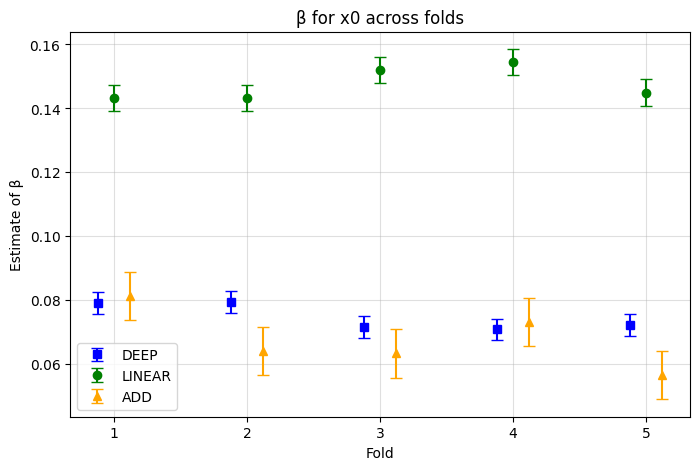

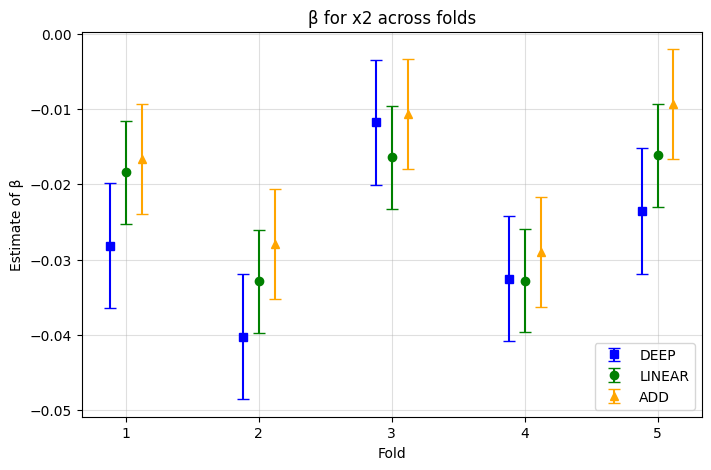

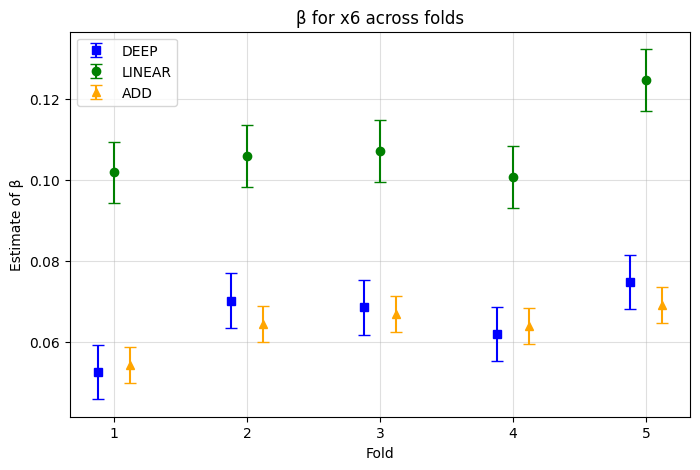

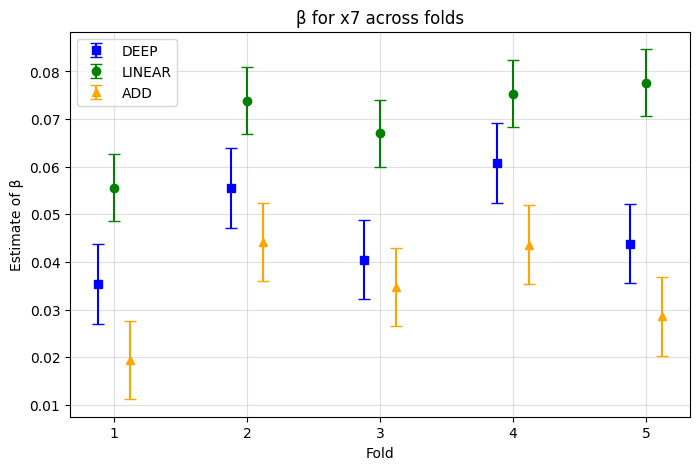

In [131]:
plot_beta_with_ci(
    results_dict = results,
    var_index = 0,
    var_name = "x0"
)

plot_beta_with_ci(
    results_dict = results,
    var_index = 1,
    var_name = "x2"
)

plot_beta_with_ci(
    results_dict = results,
    var_index = 2,
    var_name = "x6"
)

plot_beta_with_ci(
    results_dict = results,
    var_index = 3,
    var_name = "x7"
)

## 실행2

In [105]:
deep_cfg = {
    "n_layer": 2,
    "n_node": 30,
    "n_lr": 3e-4,
    "n_epoch": 300
}

results2 = train_models_kfold(
    df=support_df,
    K=5,
    time_col="duration",
    event_col="event",
    z_cols=['x0','x5','x7','x8'],
    x_cols=[c for c in support_df.columns if c not in ["duration","event","x0","x5","x7","x8"]],
    make_cs_fn=make_current_status_data,
    nodevec=np.linspace(0,1,7),
    m=5,
    deep_config=deep_cfg
)



 Fold 0 
Training Est_linear ...
[Epoch 0] loss=0.7228, c0_mean=0.6710, beta_norm=0.0020
[Epoch 50] loss=0.6615, c0_mean=0.6541, beta_norm=0.0927
[Epoch 100] loss=0.6546, c0_mean=0.6397, beta_norm=0.1385
[Epoch 150] loss=0.6503, c0_mean=0.6274, beta_norm=0.1630
Training Est_additive ...
[Additive] Epoch 0 | loss=8.4025 | c0_mean=0.7202
[Additive] Epoch 50 | loss=1.3286 | c0_mean=0.7168
[Additive] Epoch 100 | loss=1.2287 | c0_mean=0.7132
[Additive] Epoch 150 | loss=1.1553 | c0_mean=0.7095
[Additive] Epoch 200 | loss=1.1069 | c0_mean=0.7056
[Additive] Epoch 250 | loss=1.0688 | c0_mean=0.7016
Training Est_deep ...
[Epoch 0] loss=0.8870, c0_mean=0.0998
[Epoch 50] loss=0.7928, c0_mean=0.0906
[Epoch 100] loss=0.7656, c0_mean=0.0813
[Epoch 150] loss=0.7448, c0_mean=0.0719
[Epoch 200] loss=0.7271, c0_mean=0.0624
[Epoch 250] loss=0.7116, c0_mean=0.0529

 Fold 1 
Training Est_linear ...
[Epoch 0] loss=0.7282, c0_mean=0.7215, beta_norm=0.0020
[Epoch 50] loss=0.6643, c0_mean=0.7040, beta_norm=0.0

In [32]:
import numpy as np
import matplotlib.pyplot as plt

def plot_beta_with_ci(results_dict, var_index, var_name, model_order=None):
    """
    results_dict: {"deep": betas, "linear": betas, "add": betas}
                  각 betas shape = (K, p)
    var_index: 시각화할 변수 인덱스 (0~p-1)
    var_name: 시각화할 변수 이름(str)
    """

    if model_order is None:
        model_order = ["deep", "linear", "add"]

    colors = {
        "deep": "blue",
        "linear": "green",
        "add": "orange"
    }

    markers = {
        "deep": "s",
        "linear": "o",
        "add": "^"
    }

    K = list(results_dict.values())[0].shape[0]  # number of folds
    x_positions = np.arange(1, K+1)

    plt.figure(figsize=(8,5))

    for model in model_order:
        betas = results_dict[model][:, var_index]

        mean_beta = betas  # fold별 추정치
        se_beta = betas.std() / np.sqrt(K)  # folds 간 분산으로 CI 구성 (논문 스타일)
        ci_lower = mean_beta - 1.96 * se_beta
        ci_upper = mean_beta + 1.96 * se_beta

        # 같은 위치에 겹치지 않도록 offset
        offset = {"deep": -0.12, "linear": 0, "add": 0.12}[model]

        plt.errorbar(
            x_positions + offset,  # fold index + offset
            mean_beta,
            yerr=[mean_beta - ci_lower, ci_upper - mean_beta],
            fmt=markers[model],
            color=colors[model],
            capsize=4,
            label=model.upper()
        )

    plt.title(f"β for {var_name} across folds")
    plt.xlabel("Fold")
    plt.ylabel("Estimate of β")
    plt.xticks(x_positions)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()


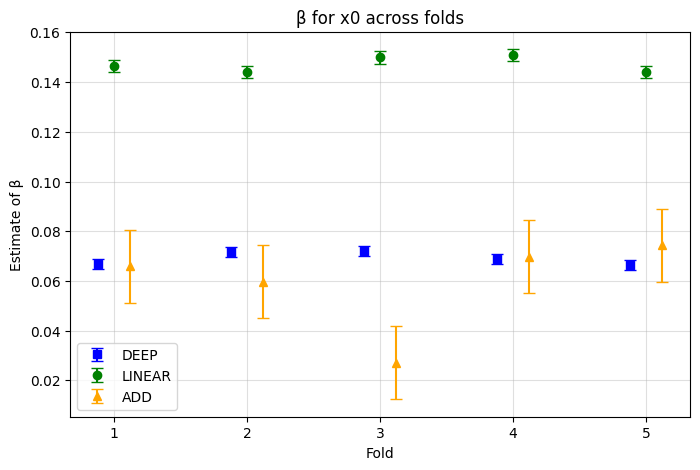

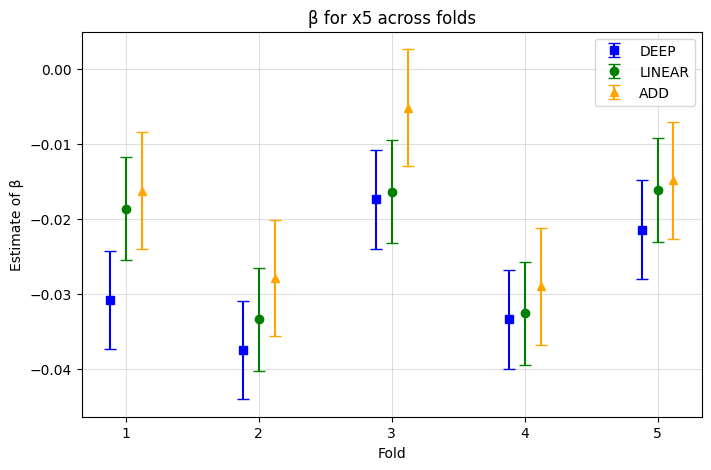

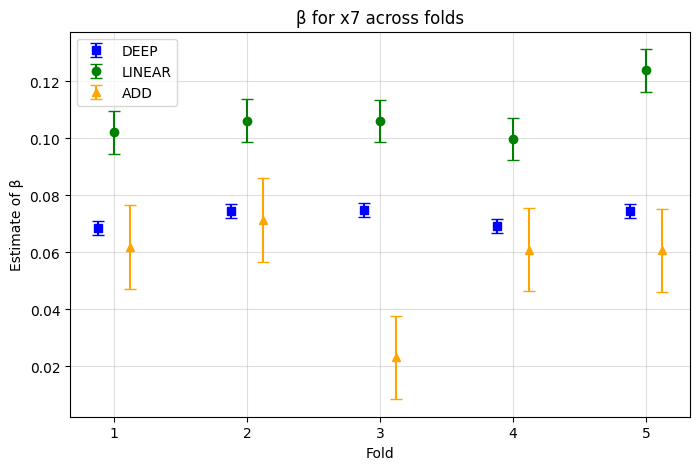

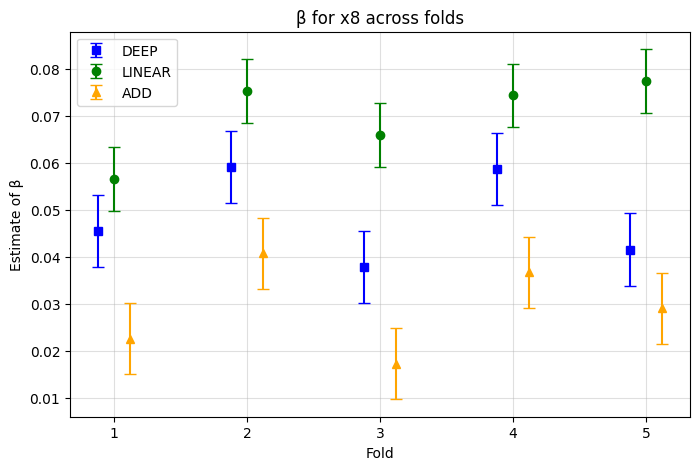

In [106]:
plot_beta_with_ci(
    results_dict = results,
    var_index = 0,
    var_name = "x0"
)


plot_beta_with_ci(
    results_dict = results,
    var_index = 1,
    var_name = "x5"
)

plot_beta_with_ci(
    results_dict = results,
    var_index = 2,
    var_name = "x7"
)
plot_beta_with_ci(
    results_dict = results,
    var_index = 3,
    var_name = "x8"
)

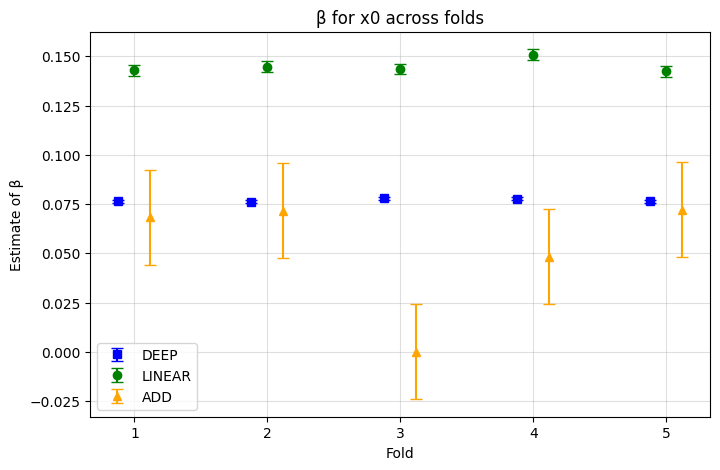

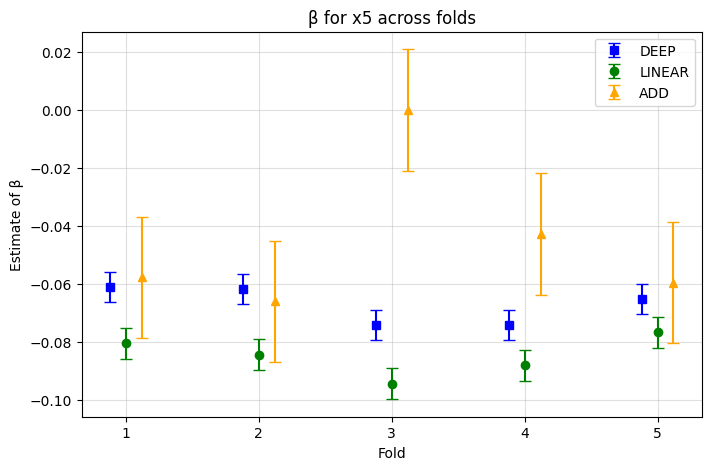

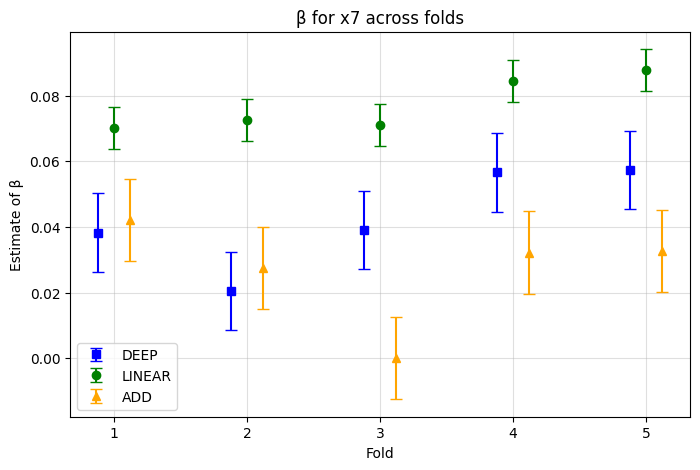

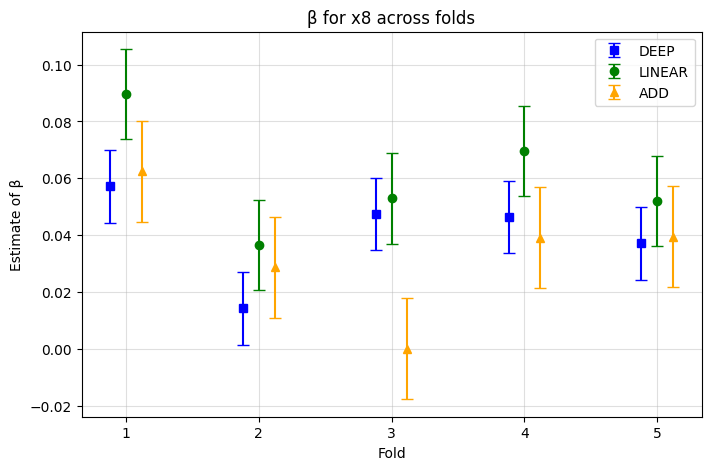

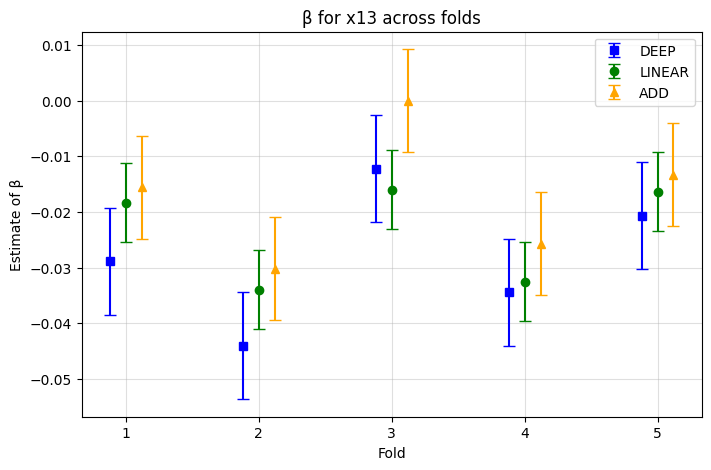

In [95]:
plot_beta_with_ci(
    results_dict = results2,
    var_index = 0,
    var_name = "x0"
)


plot_beta_with_ci(
    results_dict = results2,
    var_index = 1,
    var_name = "x5"
)

plot_beta_with_ci(
    results_dict = results2,
    var_index = 2,
    var_name = "x7"
)
plot_beta_with_ci(
    results_dict = results2,
    var_index = 3,
    var_name = "x8"
)
plot_beta_with_ci(
    results_dict = results2,
    var_index = 4,
    var_name = "x13"
)

# delta - duration quantile 시각화

In [107]:
def I_spline_eval(t_grid, c0, nodevec):
    t_grid = torch.tensor(t_grid, dtype=torch.float32)
    c0_t = torch.tensor(c0, dtype=torch.float32)
    kv = torch.tensor(nodevec, dtype=torch.float32)

    m = len(c0)
    n = len(t_grid)

    basis = torch.zeros((n, m))
    for j in range(m):
        left = kv[j]
        right = kv[j+2]
        width = max(float(right-left), 1e-6)
        b = (t_grid - left) / width
        b = torch.clamp(b, 0, 1)
        basis[:, j] = b

    Lambda = basis @ c0_t
    return Lambda.numpy()


In [108]:
def eta_linear(sample, beta_full):
    pz = len(sample["Z"])
    px = len(sample["X"])

    beta_z = beta_full[:pz]
    beta_x = beta_full[pz:pz+px]
    intercept = beta_full[-1]

    return np.dot(beta_z, sample["Z"]) + np.dot(beta_x, sample["X"]) + intercept


def eta_additive(sample, beta_vec, g_add):
    pz = len(sample["Z"])
    beta_z = beta_vec[:pz]
    intercept = beta_vec[-1]
    return np.dot(beta_z, sample["Z"]) + g_add + intercept


def eta_deep(sample, beta_z, g_deep):
    return np.dot(beta_z, sample["Z"]) + g_deep


In [109]:
def survival_curve(t_grid, eta, c0, nodevec):
    Lambda_t = I_spline_eval(t_grid, c0, nodevec)
    h_t = Lambda_t * np.exp(eta)
    S_t = np.exp(-h_t)
    return S_t
def select_case(df, q):
    target = df["C"].quantile(q)
    idx = (df["C"] - target).abs().idxmin()
    return df.loc[idx], idx


In [110]:
def plot_panel(ax, sample,
               model_linear, model_add, model_deep,
               nodevec, t_grid,
               z_cols, x_cols):

    s = {
        "Z": sample[[f"Z_{z}" for z in z_cols]].values.astype(float),
        "X": sample[x_cols].values.astype(float),
        "C": sample["C"],
        "Delta": sample["Delta"]
    }

    gA = sample["g_add"]
    gD = sample["g_deep"]

    eta_L = eta_linear(s, model_linear["Beta"])
    eta_A = eta_additive(s, model_add["Beta"], gA)
    eta_D = eta_deep(s, model_deep["Beta"], gD)

    S_L = survival_curve(t_grid, eta_L, model_linear["c"], nodevec)
    S_A = survival_curve(t_grid, eta_A, model_add["c"], nodevec)
    S_D = survival_curve(t_grid, eta_D, model_deep["c"], nodevec)

    ax.plot(t_grid, S_D, label="DPLCM", color="blue")
    ax.plot(t_grid, S_L, label="CPH",   color="green")
    ax.plot(t_grid, S_A, label="PLACM", color="orange")

    ax.axvline(s["C"], linestyle="--", color="black")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Δ={int(s['Delta'])}, C={s['C']:.1f}")
    ax.grid(True)


In [111]:
def plot_figure4(
    fold_id, results, z_cols, x_cols,
    nodevec=np.linspace(0,1,7),
    T_max=None
):
    fold = results["fold_data"][fold_id]

    model_linear = fold["linear"]
    model_add    = fold["add"]
    model_deep   = fold["deep"]

    test_df = fold["test_cs_df"].copy()

    D1 = test_df[test_df["Delta"] == 1].copy()
    D0 = test_df[test_df["Delta"] == 0].copy()

    # ---- t-grid 설정 ----
    if T_max is None:
        T_max = test_df["C"].max() * 1.2
    t_grid = np.linspace(0, T_max, 300)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    qs = [0.25, 0.50, 0.75]

    # -----------------------
    #   Δ = 1 (위 row)
    # -----------------------
    for j, q in enumerate(qs):
        sample, idx = select_case(D1, q)
        plot_panel(
            axes[0][j], sample,
            model_linear, model_add, model_deep,
            nodevec, t_grid,
            z_cols, x_cols
        )
        axes[0][j].set_title(f"Δ=1, C={sample['C']:.2f}")

    # -----------------------
    #   Δ = 0 (아래 row)
    # -----------------------
    for j, q in enumerate(qs):
        sample, idx = select_case(D0, q)
        plot_panel(
            axes[1][j], sample,
            model_linear, model_add, model_deep,
            nodevec, t_grid,
            z_cols, x_cols
        )
        axes[1][j].set_title(f"Δ=0, C={sample['C']:.2f}")

    # legend (전체 figure 오른쪽 위)
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    plt.tight_layout()
    plt.show()


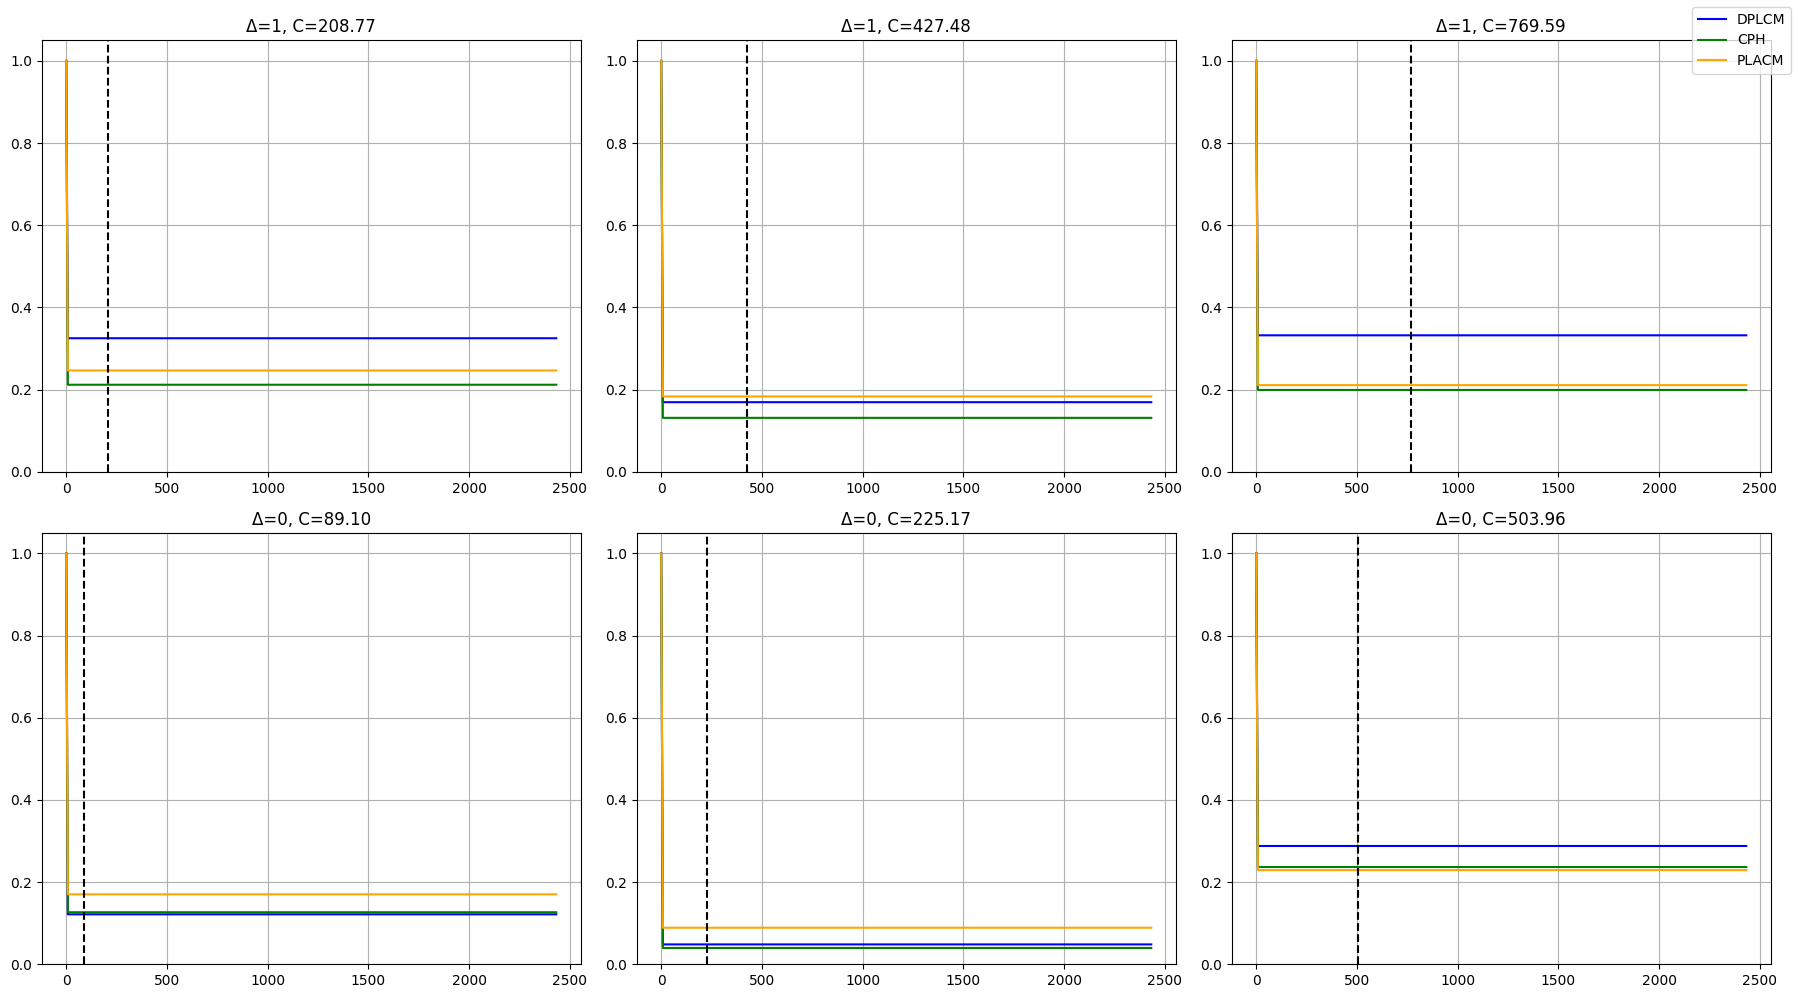

In [134]:
plot_figure4(
    fold_id=0,
    results=results,
    z_cols=results["z_cols_expanded"],
    x_cols=results["x_cols_expanded"]
)


In [67]:
fold = results["fold_data"][0]
print("keys:", fold.keys())
print("test_cs_df rows:", fold["test_cs_df"].shape)
print("Delta counts:", fold["test_cs_df"]["Delta"].value_counts())


keys: dict_keys(['linear', 'add', 'deep', 'test_idx', 'test_cs_df'])
test_cs_df rows: (1775, 25)
Delta counts: Delta
1    935
0    840
Name: count, dtype: int64


In [ ]:
def pick_noevent_representatives(U_test, De_test, q=[0.25, 0.5, 0.75]):
    """
    Δ=0 subset에서 duration(U)의 분위수에 가장 가까운 환자 3명을 선택.
    """
    idx0 = np.where(De_test == 0)[0]
    U0 = U_test[idx0]

    reps = []
    for qi in q:
        target = np.quantile(U0, qi)
        diff = np.abs(U0 - target)
        chosen = idx0[np.argmin(diff)]
        reps.append(chosen)

    return reps


In [ ]:
k = 0
res = results[k]

rep_noevent = pick_noevent_representatives(
    res["U_test"], res["De_test"],
    q=[0.25, 0.5, 0.75]
)

print(rep_noevent)
# 예: [1464, 831, 1107]


[np.int64(1464), np.int64(831), np.int64(1107)]


각 모델별 S(t) 계산함수

In [ ]:
def predict_survival_for_one(i, model, results_k, t_grid, nodevec):
    Z_i = results_k["Z_test"][i]
    X_i = results_k["X_test"][i]

    if model == "de":
        g = results_k["g_te_de"][i]
        beta = results_k["beta_de"]
        c0  = results_k["c_de"]
        eta_i = Z_i @ beta + g

    elif model == "L":
        beta_full = results_k["beta_L"]
        p_z = results_k["Z_test"].shape[1]
        p_x = results_k["X_test"].shape[1]

        beta_z = beta_full[:p_z]
        beta_x = beta_full[p_z:p_z+p_x]
        intercept = beta_full[-1]
        eta_i = Z_i @ beta_z + X_i @ beta_x + intercept
        c0 = results_k["c_L"]

    else:  # Additive
        g = results_k["g_te_A"][i]
        beta = results_k["beta_A"]
        p_z = results_k["Z_test"].shape[1]
        beta_z = beta[:p_z]
        intercept = beta[-1]
        eta_i = Z_i @ beta_z + g + intercept
        c0 = results_k["c_A"]

    Lambda_t = Lambda_hat(t_grid, c0, nodevec)
    S_t = survival_curve(Lambda_t, eta_i)
    return S_t


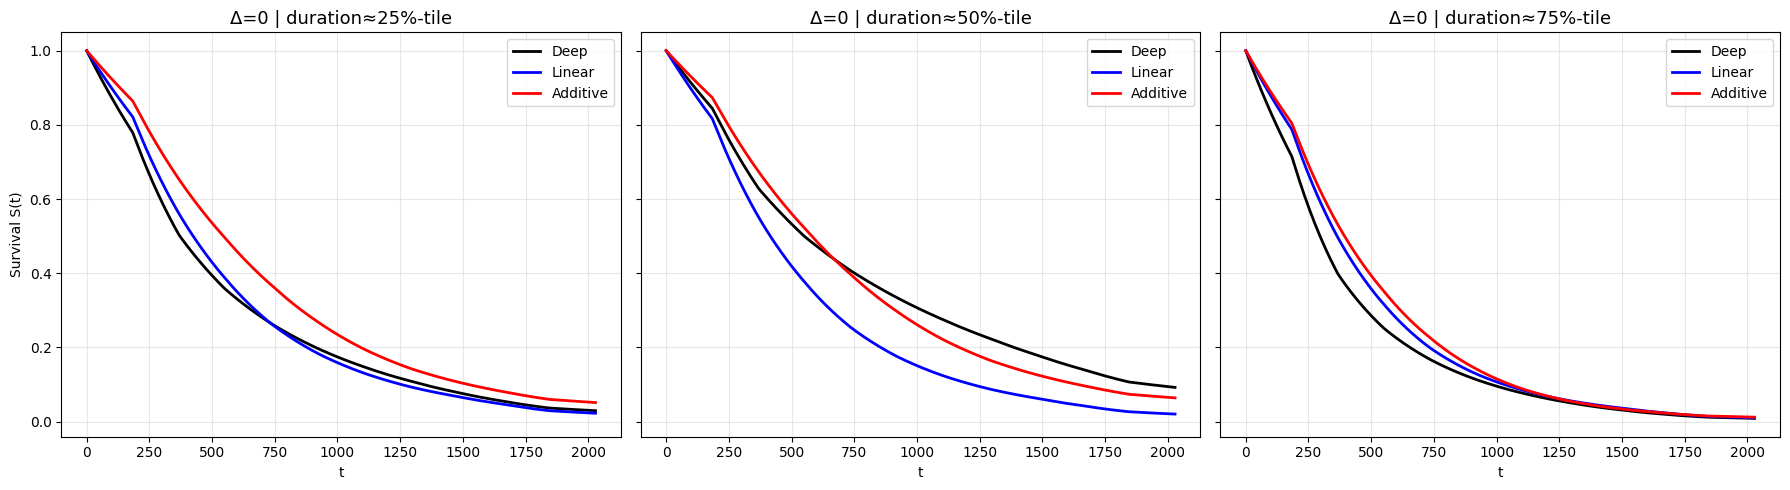

In [ ]:
import matplotlib.pyplot as plt

t_grid = np.linspace(0, tau, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = ["de", "L", "A"]
titles = ["Deep", "Linear", "Additive"]
colors = ["black", "blue", "red"]

for j, idx_i in enumerate(rep_noevent):
    ax = axes[j]

    for model, col, title in zip(models, colors, titles):
        S_t = predict_survival_for_one(idx_i, model, res, t_grid, nodevec)
        ax.plot(t_grid, S_t, color=col, label=title, linewidth=2)

    ax.set_title(f"Δ=0 | duration≈{[0.25,0.5,0.75][j]*100:.0f}%-tile", fontsize=13)
    ax.set_xlabel("t")
    if j == 0:
        ax.set_ylabel("Survival S(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


for delta = 1

In [ ]:
def pick_event_representatives(U_test, De_test, q=[0.25, 0.5, 0.75]):
    """
    Δ=1 subset에서 duration(U)의 분위수에 가장 가까운 환자 3명을 선택.
    """
    idx1 = np.where(De_test == 1)[0]
    U1 = U_test[idx1]

    reps = []
    for qi in q:
        target = np.quantile(U1, qi)
        diff = np.abs(U1 - target)
        chosen = idx1[np.argmin(diff)]
        reps.append(chosen)

    return reps


In [ ]:
k = 0
res = results[k]

rep_event = pick_event_representatives(
    res["U_test"], res["De_test"],
    q=[0.25, 0.5, 0.75]
)

print(rep_event)   # 예: [670, 1202, 289]


[np.int64(670), np.int64(1202), np.int64(289)]


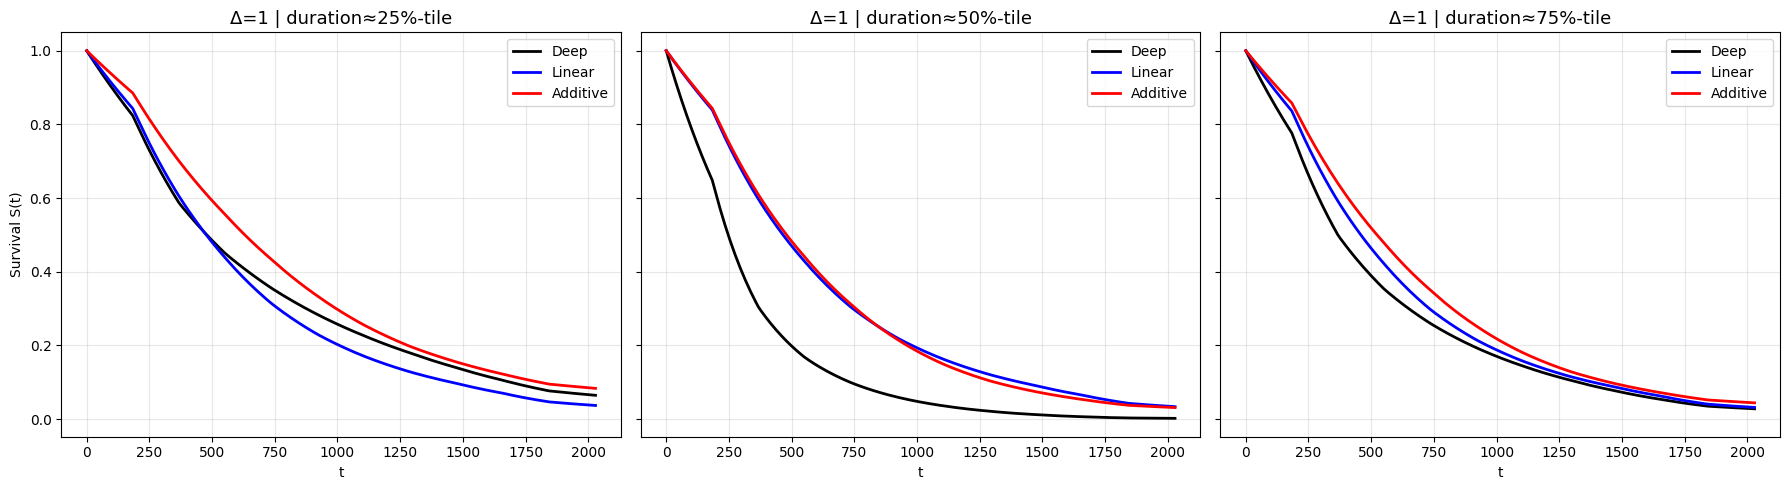

In [ ]:
t_grid = np.linspace(0, tau, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

models = ["de", "L", "A"]
titles = ["Deep", "Linear", "Additive"]
colors = ["black", "blue", "red"]

# Δ=1 대표 세 환자 index
q_vals = [0.25, 0.5, 0.75]
for j, idx_i in enumerate(rep_event):
    ax = axes[j]

    for model, col, title in zip(models, colors, titles):
        S_t = predict_survival_for_one(idx_i, model, res, t_grid, nodevec)
        ax.plot(t_grid, S_t, color=col, label=title, linewidth=2)

    ax.set_title(f"Δ=1 | duration≈{q_vals[j]*100:.0f}%-tile", fontsize=13)
    ax.set_xlabel("t")
    if j == 0:
        ax.set_ylabel("Survival S(t)")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()


# cumulative **hazard**

results에서 c_de, c_L, c_A 다 뽑아써야함

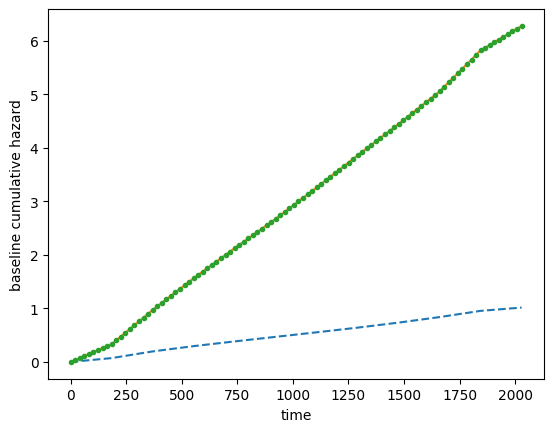

In [ ]:
t_grid1 = np.linspace(0, tau, 100).astype("float32")
t_grid2 = np.linspace(0, tau, 100).astype("float32")
t_grid3 = np.linspace(0, tau, 100).astype("float32")

# --- torch-based baseline cumulative hazard ---
def I_spline_torch_single_time(m, c0_np, t, nodevec):
    c0 = torch.tensor(c0_np, dtype=torch.float32)
    t_tensor = torch.tensor([t], dtype=torch.float32)
    return I_spline_torch(m, c0, t_tensor, nodevec)[0].item()

Lambda_list1 = []
for t in t_grid1:
    Lambda_list1.append(
        I_spline_torch_single_time(
            m,          # torch model's m
            c_de,       # learned coefficients
            t,
            nodevec     # torch version nodevec
        )
    )

Lambda_list2 = []
for t in t_grid2:
    Lambda_list2.append(
        I_spline_torch_single_time(
            m,          # torch model's m
            c_L,       # learned coefficients
            t,
            nodevec     # torch version nodevec
        )
    )

Lambda_list3 = []
for t in t_grid3:
    Lambda_list3.append(
        I_spline_torch_single_time(
            m,          # torch model's m
            c_A,       # learned coefficients
            t,
            nodevec     # torch version nodevec
        )
    )

Lambda_de = np.array(Lambda_list1)
Lambda_L = np.array(Lambda_list2)
Lambda_A = np.array(Lambda_list3)

plt.plot(t_grid1, Lambda_de, '--')
plt.plot(t_grid2, Lambda_L, '-')
plt.plot(t_grid3, Lambda_L, '.')

plt.xlabel("time")
plt.ylabel("baseline cumulative hazard")
plt.show()


# Beta 그래프

# beta 시각화

In [ ]:
# ----------------------------
# 1. fold별 beta 수집
# ----------------------------
beta_de_all = []
beta_L_all  = []
beta_A_all  = []

for fold in range(len(results)):
    beta_de_all.append(results[fold]["beta_de"])
    beta_L_all.append(results[fold]["beta_L"])
    beta_A_all.append(results[fold]["beta_A"])

beta_de_all = np.array(beta_de_all, dtype=object)
beta_L_all  = np.array(beta_L_all, dtype=object)
beta_A_all  = np.array(beta_A_all, dtype=object)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_beta_ci_folds_offset(beta_de_Z, beta_L_Z, beta_A_Z, var_names):
    """
    beta_*_Z : shape (K, p_z)
    var_names : list of variable names in Z (length p_z)
    """

    K, p_z = beta_de_Z.shape
    folds = np.arange(1, K + 1)

    # 모델 사양 + offset
    model_specs = {
        "Deep":     {"beta": beta_de_Z, "color": "blue",  "marker": "s", "offset": -0.15},
        "Linear":   {"beta": beta_L_Z,  "color": "orange","marker": "o", "offset":  0.00},
        "Additive": {"beta": beta_A_Z,  "color": "green", "marker": "^", "offset": +0.15},
    }

    for j in range(p_z):  # 각 beta_j 에 대해 그림 하나 생성
        plt.figure(figsize=(8, 5))

        for model_name, spec in model_specs.items():
            beta_j = spec["beta"][:, j]   # shape (K,)
            color  = spec["color"]
            marker = spec["marker"]
            offset = spec["offset"]

            # offset 적용된 x좌표
            x_pos = folds + offset

            # point
            plt.scatter(x_pos, beta_j, color=color, marker=marker, s=60, label=model_name)

            # fold 간 sd 기반 CI width
            beta_sd = np.std(beta_j, ddof=1)
            ci_low  = beta_j - 1.96 * beta_sd
            ci_high = beta_j + 1.96 * beta_sd

            # error bars (model별 offset 적용)
            for f in range(K):
                plt.plot([x_pos[f], x_pos[f]], [ci_low[f], ci_high[f]],
                         color=color, linewidth=2)

        plt.title(f"β for {var_names[j]} across folds", fontsize=14)
        plt.xlabel("Fold")
        plt.ylabel("Estimate")

        plt.xticks(folds)  # 폴드 번호는 중심에 그대로
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


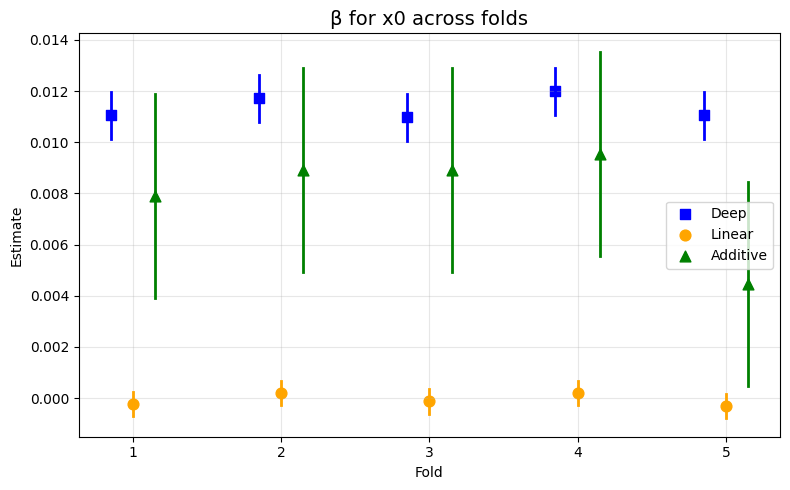

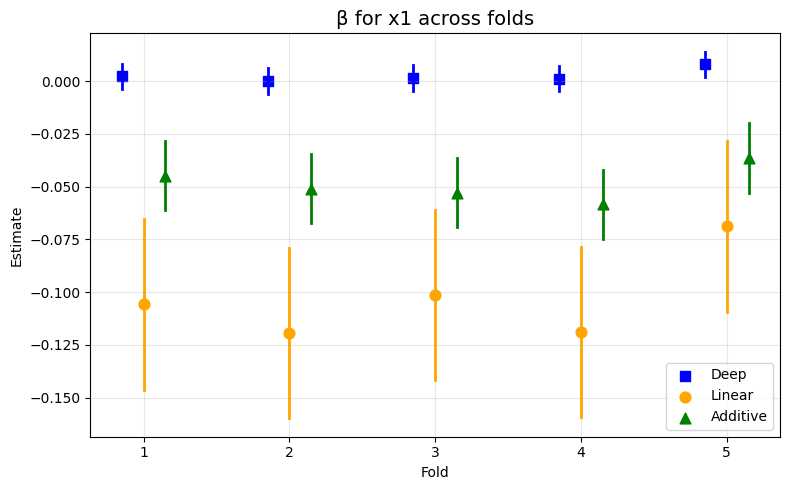

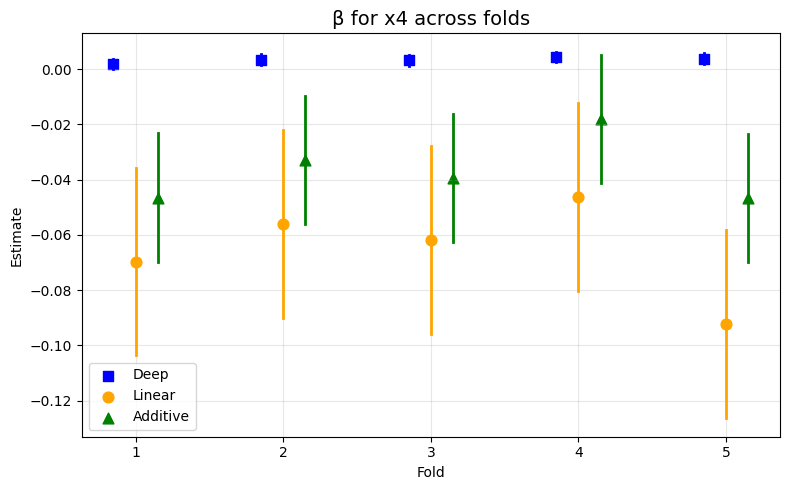

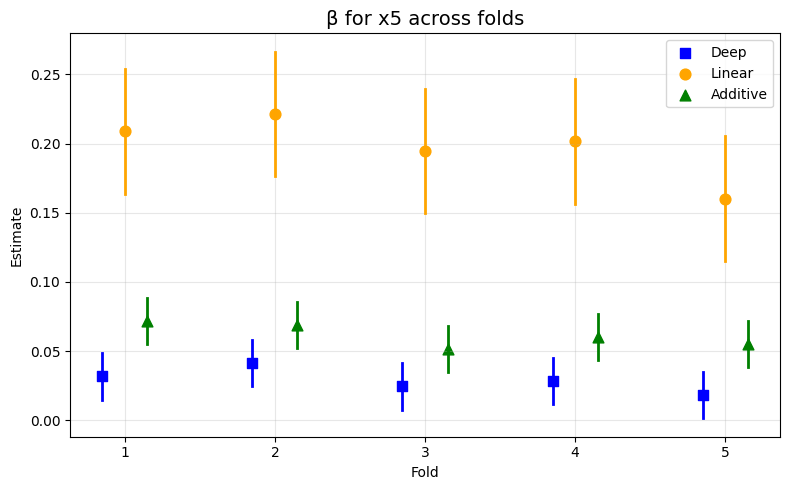

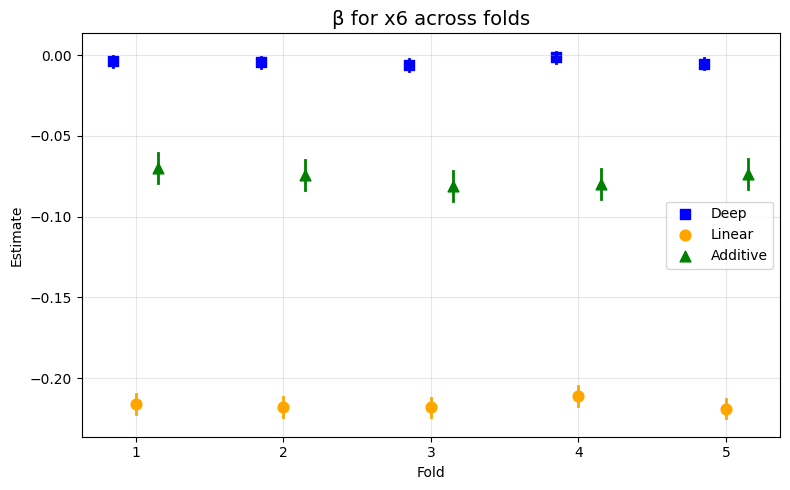

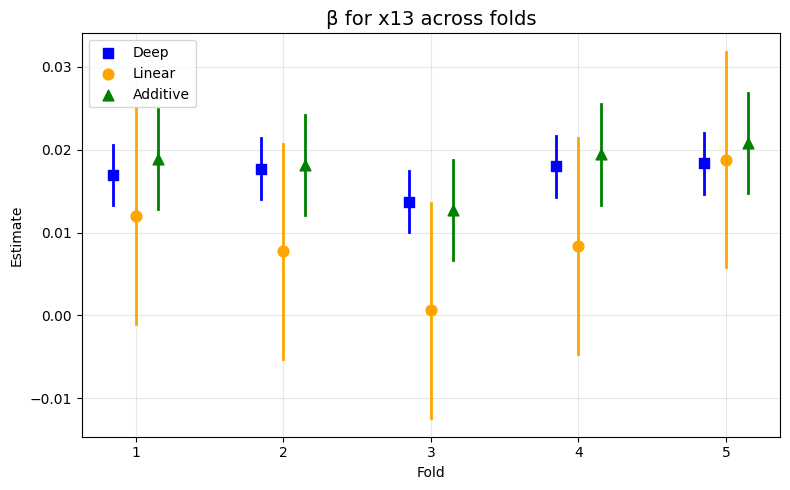

In [ ]:
p_z = len(Z_cols)

beta_de_Z = np.vstack([b[:p_z] for b in beta_de_all])
beta_L_Z  = np.vstack([b[:p_z] for b in beta_L_all])
beta_A_Z  = np.vstack([b[:p_z] for b in beta_A_all])

plot_beta_ci_folds_offset(beta_de_Z, beta_L_Z, beta_A_Z, Z_cols)
